In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import os
import pandas as pd
import tensorflow as tf
from tensorflow import keras

In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 1. Copy the zip from Drive to Colab's local disk
!cp /content/drive/MyDrive/ISIC-Skin-cancer-dataset/jpeg-melanoma-256x256.zip /content/

# 2. Unzip it locally for the training session
!unzip -q jpeg-melanoma-256x256.zip -d /content/melanoma_data/

In [5]:
!cp /content/drive/MyDrive/ISIC-training-csv/ISIC_2020_Train_Metadata.csv.zip /content/

!unzip -q /content/ISIC_2020_Train_Metadata.csv.zip -d /content/training_metadata-csv/


In [6]:
# now we have got our data locally
CSV_PATH = "/content/training_metadata-csv/ISIC_2020_Train_Metadata.csv"

In [7]:
IMG_DIR = "/content/melanoma_data/train"

In [8]:
df = pd.read_csv(CSV_PATH)

In [9]:
len(df)

33126

In [10]:
list(df.columns)

['image_name',
 'patient_id',
 'lesion_id',
 'sex',
 'age_approx',
 'anatom_site_general_challenge',
 'diagnosis',
 'benign_malignant',
 'target']

In [11]:
df.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0


In [12]:
print(f"Total patients: {df['patient_id'].nunique()}")
print(f"Total images: {len(df)}")

Total patients: 2056
Total images: 33126


In [13]:
df.isnull().sum()

,0
image_name,0
patient_id,0
lesion_id,0
sex,65
age_approx,68
anatom_site_general_challenge,527
diagnosis,0
benign_malignant,0
target,0


In [14]:
# Handling the missing values of age
median_age = df['age_approx'].median()
print(median_age)

# To fill null values with median age
df['age_approx'] = df['age_approx'].fillna(median_age)
df.isnull().sum()

50.0


,0
image_name,0
patient_id,0
lesion_id,0
sex,65
age_approx,0
anatom_site_general_challenge,527
diagnosis,0
benign_malignant,0
target,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33126 entries, 0 to 33125
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     33126 non-null  object 
 1   patient_id                     33126 non-null  object 
 2   lesion_id                      33126 non-null  object 
 3   sex                            33061 non-null  object 
 4   age_approx                     33126 non-null  float64
 5   anatom_site_general_challenge  32599 non-null  object 
 6   diagnosis                      33126 non-null  object 
 7   benign_malignant               33126 non-null  object 
 8   target                         33126 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 2.3+ MB


In [16]:
# fill the sex,  values with unknown
df['sex'] = df['sex'].fillna('unknown')
df['anatom_site_general_challenge'] = df['anatom_site_general_challenge'].fillna('unknown')

df.isnull().sum()

,0
image_name,0
patient_id,0
lesion_id,0
sex,0
age_approx,0
anatom_site_general_challenge,0
diagnosis,0
benign_malignant,0
target,0


In [17]:
df['target'].sum()

np.int64(584)

In [18]:
df['target'].mean()

np.float64(0.01762965646320111)

In [19]:
df['sex'].unique()

array(['male', 'female', 'unknown'], dtype=object)

In [20]:
df['anatom_site_general_challenge'].unique()

array(['head/neck', 'upper extremity', 'lower extremity', 'torso',
       'unknown', 'palms/soles', 'oral/genital'], dtype=object)

In [21]:
df['diagnosis'].unique()

array(['unknown', 'nevus', 'melanoma', 'seborrheic keratosis',
       'lentigo NOS', 'lichenoid keratosis', 'solar lentigo',
       'cafe-au-lait macule', 'atypical melanocytic proliferation'],
      dtype=object)

In [22]:
df['benign_malignant'].unique()

array(['benign', 'malignant'], dtype=object)

In [23]:
df.describe()

,age_approx,target
count,33126.000000,33126.000000
mean,48.872336,0.017630
std,14.365684,0.131603
min,0.000000,0.000000
25%,40.000000,0.000000
50%,50.000000,0.000000
75%,60.000000,0.000000
max,90.000000,1.000000


# EDA:
#### Class Distribution
- The ISIC 2020 dataset is **heavily imbalanced**
- Only ~1.8% of samples are malignant
- This is why we use Focal Loss + oversampling

In [24]:
benign_count = (df['target'] == 0).sum()
malignant_count = (df['target'] == 1).sum()
print(f"benign count: {benign_count}")
print(f"malignant count: {malignant_count}")

benign count: 32542
malignant count: 584


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

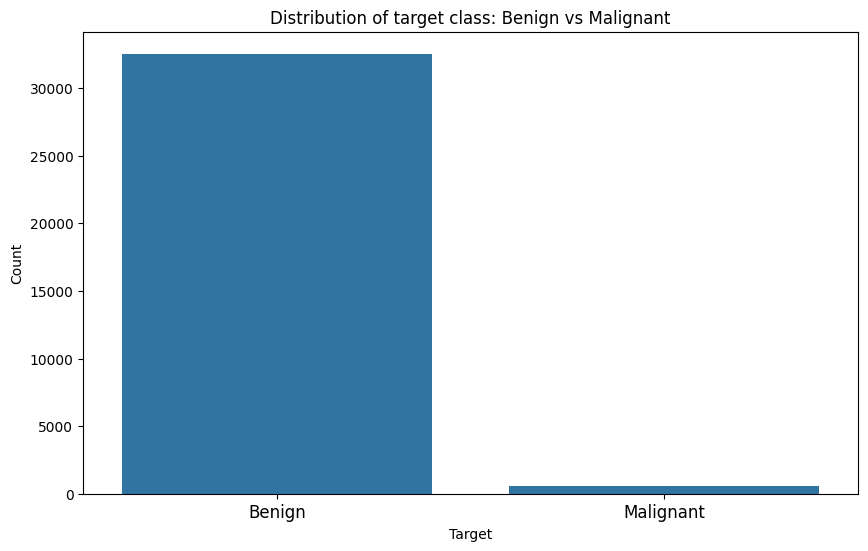

Benign: 32542
Malignant: 584


In [26]:
# Class distrubition
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='target')
plt.title('Distribution of target class: Benign vs Malignant')
plt.xticks([0, 1], ['Benign', 'Malignant'], fontsize=12)
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

# Showing the real values
print(f"Benign: {benign_count}")
print(f"Malignant: {malignant_count}")

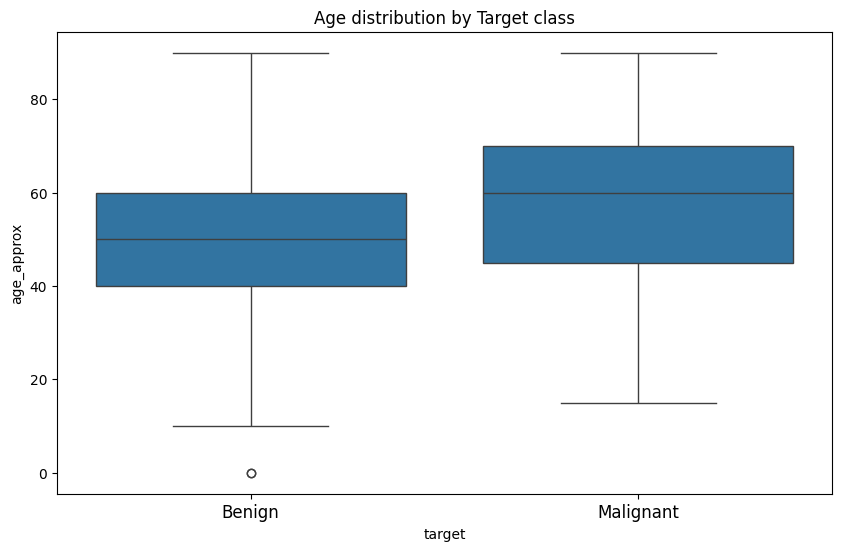

In [27]:
# Patient age vs target
plt.figure(figsize= (10, 6))
sns.boxplot(x='target', y='age_approx', data=df)
plt.xticks([0, 1], ['Benign', 'Malignant'], fontsize=12)
plt.title('Age distribution by Target class')
plt.show()

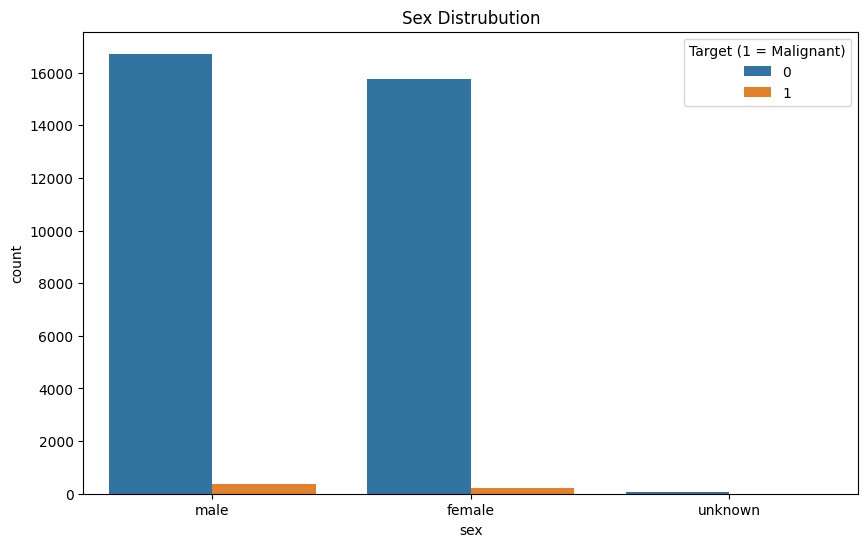

Male having malignant: 364
Female having malignant: 220
Gender not given : 0


In [28]:
# Sex distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sex', hue='target')
plt.title('Sex Distrubution')
plt.legend(title='Target (1 = Malignant)')
plt.show()



male_malignant = ((df['sex']=='male')&(df['target'] == 1)).sum()
female_malignant =  ((df['sex']=='female')&(df['target'] == 1)).sum()
unknown = ((df['sex']=='unknown')&(df['target'] == 1)).sum()

print(f"Male having malignant: {male_malignant}")
print(f"Female having malignant: {female_malignant}")
print(f"Gender not given : {unknown}")

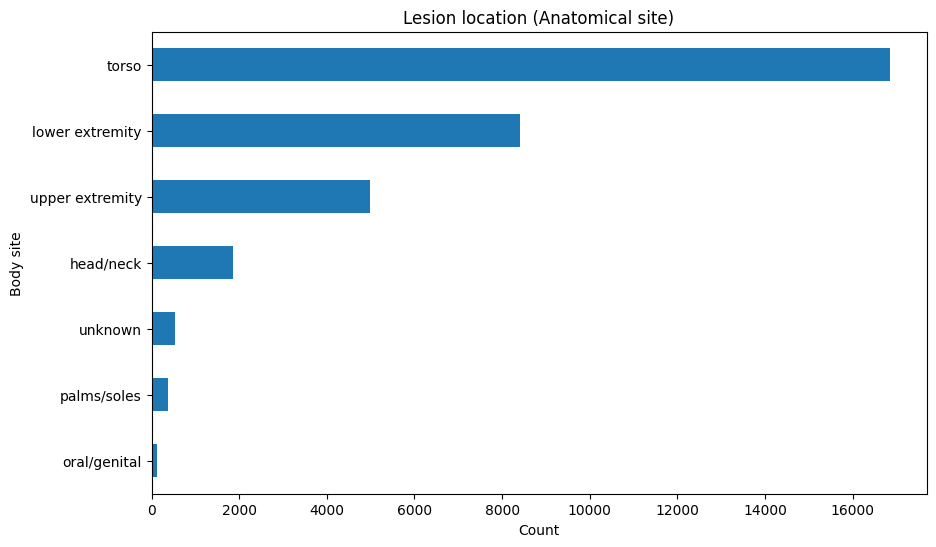

In [29]:
# Anatomical site distribution
plt.figure(figsize=(10, 6))
df['anatom_site_general_challenge'].value_counts().plot(kind='barh')
plt.title("Lesion location (Anatomical site)")

plt.xlabel('Count')
plt.ylabel('Body site')
plt.gca().invert_yaxis()
plt.show()

In [30]:
df.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0


In [31]:
site_malignant = df.groupby('anatom_site_general_challenge')['target'].mean()
site_malignant

,target
anatom_site_general_challenge,
head/neck,0.039892
lower extremity,0.014732
oral/genital,0.032258
palms/soles,0.013333
torso,0.015257
unknown,0.017078
upper extremity,0.022276


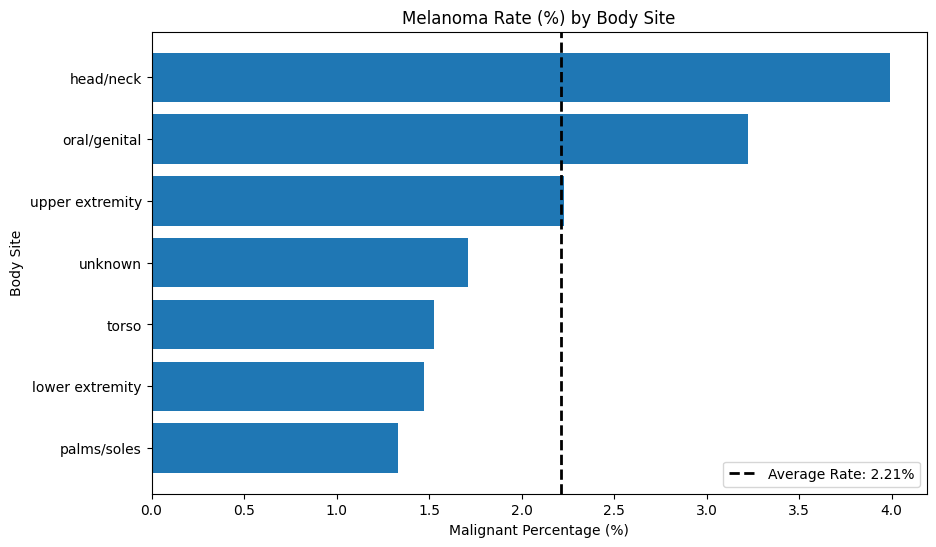

In [32]:
import matplotlib.pyplot as plt

# 1. Calculate the percentage of malignant cases per anatomical site
site_malignant = df.groupby('anatom_site_general_challenge')['target'].mean() * 100
site_malignant = site_malignant.sort_values(ascending=True)

# 2. Calculate the overall average across all sites
average_rate = site_malignant.mean()

# 4. Start the clean, standalone plot
plt.figure(figsize=(10, 6))
bars = plt.barh(site_malignant.index, site_malignant.values)

# Add the vertical average line
plt.axvline(average_rate, color='black', linestyle='--', linewidth=2, label=f'Average Rate: {average_rate:.2f}%')

# Formatting
plt.title("Melanoma Rate (%) by Body Site")
plt.xlabel("Malignant Percentage (%)")
plt.ylabel("Body Site")

# Add a 15% buffer to the x-axis so the text labels don't get cut off
plt.legend()
plt.show()

In [33]:
imgs_per_patient = df.groupby('patient_id').size().mean()
imgs_per_patient

np.float64(16.111867704280154)

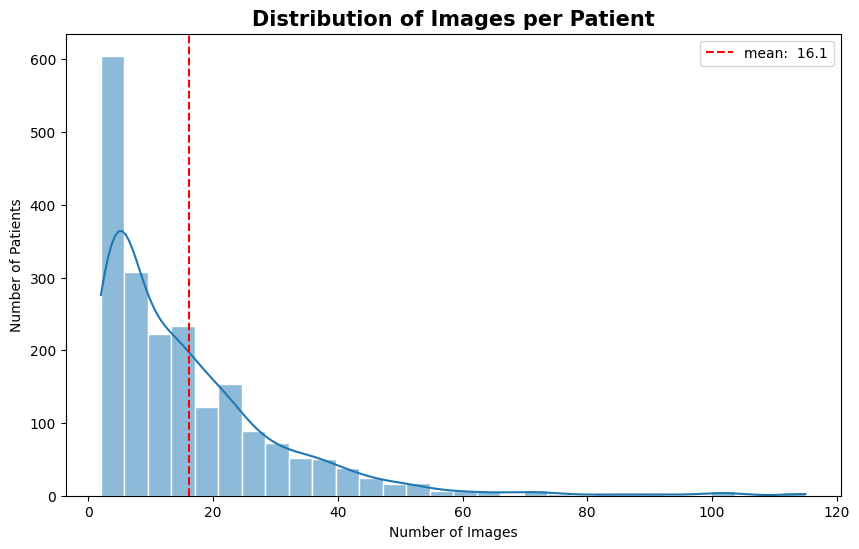

In [34]:
imgs_per_patient = df.groupby('patient_id').size()
mean_val = imgs_per_patient.mean()

plt.figure(figsize=(10, 6))
sns.histplot(imgs_per_patient, bins=30, kde=True, edgecolor='white')
plt.axvline(mean_val, color='red', linestyle='--', label=f"mean: {mean_val: .1f}")

plt.title("Distribution of Images per Patient", fontsize=15, fontweight='bold')
plt.xlabel("Number of Images")
plt.ylabel("Number of Patients")
plt.legend()
plt.show()

* This graph shows that we cannot split the images randomly in the training and the validation set.

* If say, a patient has 60 images and 40 of them are in training and 20 went to. validation set.
* Then the model will just memorize that specific skin type. So we need to use `GroupKFold`.


## Looking at the raw image

In [35]:
def load_image(image_name):
  path = os.path.join(IMG_DIR, image_name + '.jpg')
  img = cv2.imread(path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  return img

In [36]:
df[df['target'] == 1]['image_name'].values[:4]

array(['ISIC_0149568', 'ISIC_0188432', 'ISIC_0207268', 'ISIC_0232101'],
      dtype=object)

In [37]:
# Get some benign and malignant images
benign_samples = df[df['target'] == 0]['image_name'].values[:4]
malignant_samples = df[df['target'] == 1]['image_name'].values[:4]

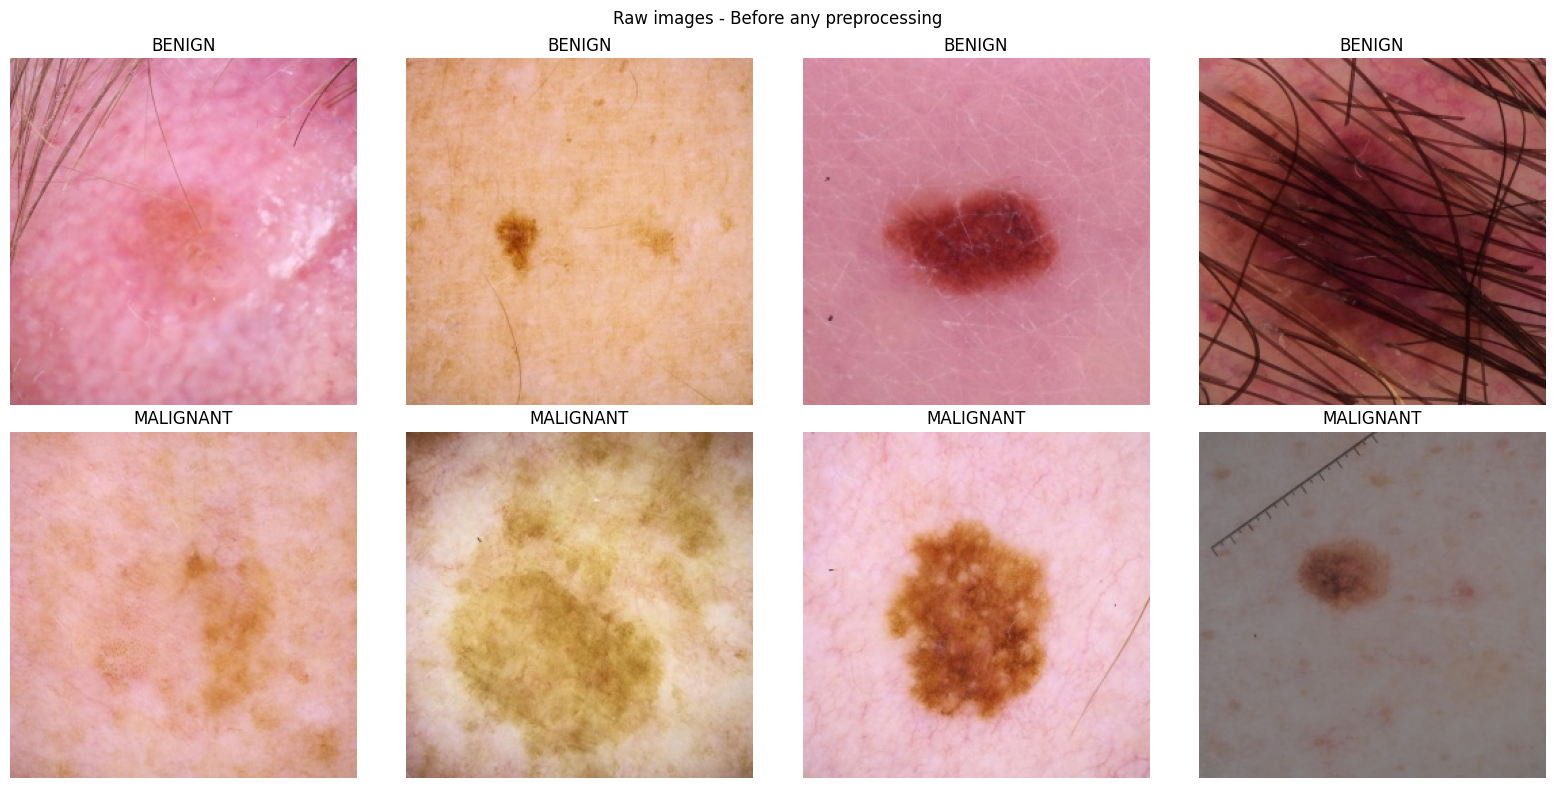

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Raw images - Before any preprocessing')

for i, name in enumerate(benign_samples):
  img = load_image(name)
  axes[0, i].imshow(img)
  axes[0, i].set_title('BENIGN')
  axes[0, i].axis('off')

for i, name in enumerate(malignant_samples):
  img = load_image(name)
  axes[1, i].imshow(img)
  axes[1, i].set_title('MALIGNANT')
  axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# OpenCV Preprocessing pipeline

In [39]:
def remove_hair(img):
  """
    DullRazor hair removal technique.

    How it works:
    1. Convert to grayscale
    2. Black-hat morphological filter — finds thin dark structures (hairs)
    3. Threshold to get a binary hair mask
    4. Inpaint (fill in) the hair pixels using surrounding skin pixels
  """

  # Tensorflow to numpy bridge
  if isinstance(img, tf.Tensor):
    img = img.numpy()

  # To correct tensorflow and OpenCV mismatch
  was_normalized = False
  if img.dtype in [np.float32, np.float64] and img.max()<=1.0:
    img = (img*255).astype(np.uint8)
    was_normalized=True

  elif img.dtype != np.uint8:
    img = img.astype(np.uint8)

  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

  # Black-hat filter:Black-Hat Morphology is mathematically designed to extract dark, thin structures (hairs) against a bright background (skin). It isolates only the hair.
  #Shrink the kernel to 5x5 for 256px images
  # kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
  kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
  blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

  # Threshold to create hair mask
  # Pixel brighther than 15 in blackhat = hair
  _, hair_mask = cv2.threshold(blackhat, 15, 255, cv2.THRESH_BINARY)

  # Inpaint — fill hair pixels using nearby skin color
  # radius=3 means it looks 3 pixels around each masked pixel
  cleaned = cv2.inpaint(img, hair_mask,
                        inpaintRadius=2,
                        flags=cv2.INPAINT_TELEA)

  return cleaned, hair_mask

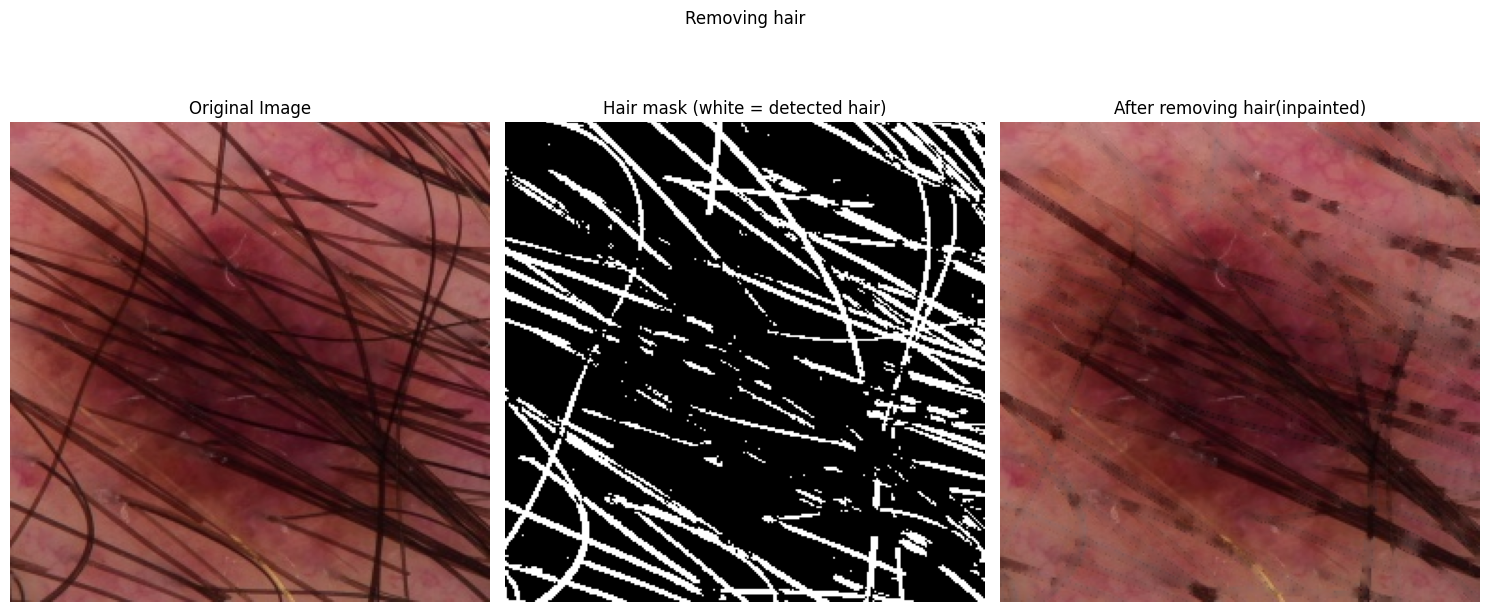

In [40]:
# Test on a hairy image
test_img = load_image(benign_samples[3])

cleaned_img, hair_mask = remove_hair(test_img)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.suptitle('Removing hair')

axes[0].imshow(test_img)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(hair_mask, cmap='gray')
axes[1].set_title('Hair mask (white = detected hair)')
axes[1].axis('off')

axes[2].imshow(cleaned_img)
axes[2].set_title('After removing hair(inpainted)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

In [41]:
# Color constancy(shades of gray)
def color_constancy(img, power=6):
  """
  How it works:
  Different clinics have different lighting.
  This normalizes the image so the illumination effect is removed.
  The model then learns from the lesion not the lighting.

  power=6 is the standard value used in dermoscopy literature.
  """
  img_float = img.astype(np.float32)

  # compute the p-norm for each channel
  norm_per_channel = np.power(
      np.mean(np.power(img_float, power), axis=(0, 1)),
      1.0/power
  )
  # For each color channel (Red, Green, Blue), it takes every pixel, raises it to the power of 6, calculates the average (np.mean), and then takes the 6th root (1.0/power)

  # Compute the overall illuminant
  overall_norm = np.power(
     np.mean((np.power(norm_per_channel, 2))),
     1.0/2
  )

  # Scale each channel to normalize illuminant
  img_constancy = img_float * (overall_norm/(norm_per_channel+ 1e-6))

  # clip to valid range and convert back to uint8
  img_constancy = np.clip(img_constancy, 0, 255).astype(np.uint8)

  return img_constancy


In [42]:
test_img = load_image(benign_samples[1])

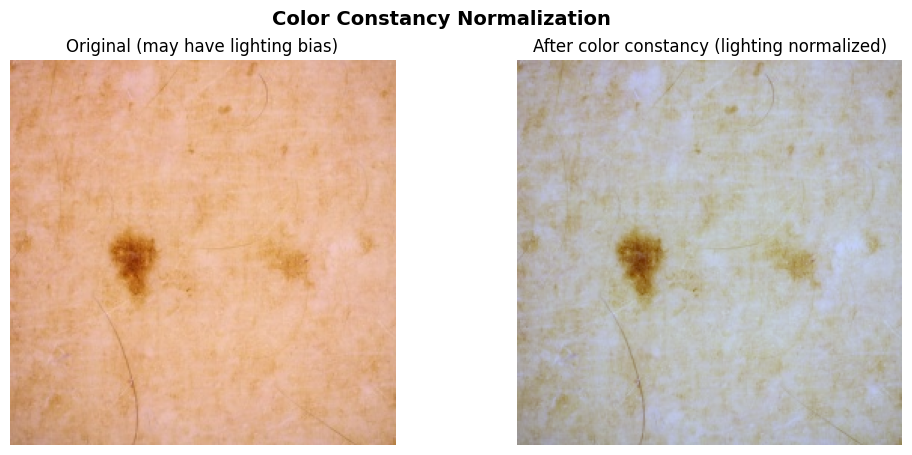

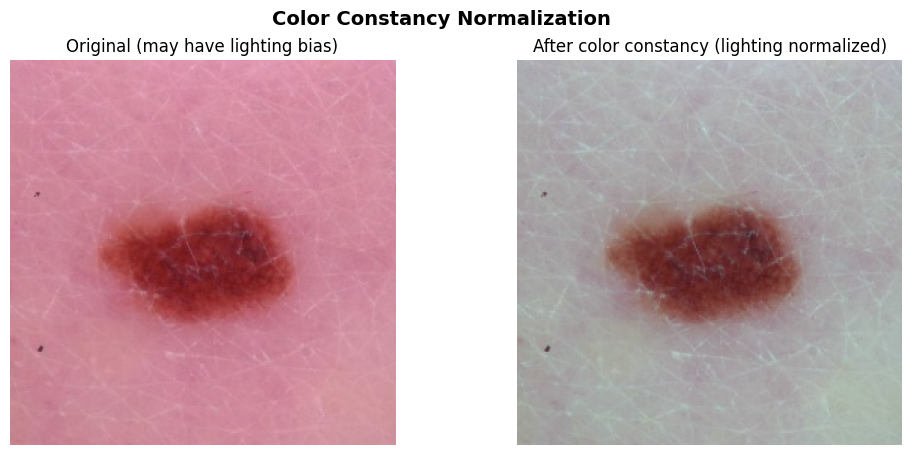

In [43]:
# Test
test_img = load_image(benign_samples[1])
color_corrected = color_constancy(test_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Color Constancy Normalization', fontsize=14, fontweight='bold')

axes[0].imshow(test_img)
axes[0].set_title('Original (may have lighting bias)')
axes[0].axis('off')

axes[1].imshow(color_corrected)
axes[1].set_title('After color constancy (lighting normalized)')
axes[1].axis('off')

plt.show()

# Test 2
test_img = load_image(benign_samples[2])

color_corrected = color_constancy(test_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Color Constancy Normalization', fontsize=14, fontweight='bold')

axes[0].imshow(test_img)
axes[0].set_title('Original (may have lighting bias)')
axes[0].axis('off')

axes[1].imshow(color_corrected)
axes[1].set_title('After color constancy (lighting normalized)')
axes[1].axis('off')

plt.show()


#### What is a surgical marker artifact?
Before a dermatologist takes a dermoscopy photo, they sometimes draw on the skin with a blue or purple marker pen — to mark the boundary of the lesion, or to label which lesion needs biopsy. These ink marks show up in the photo as bright blue/purple blobs that have nothing to do with the actual skin condition. If you leave them in, the model might learn `blue blobs = malignant`instead of learning the actual lesion features.

In [44]:
def remove_artifacts(img):
    """
    Remove surgical marker ink artifacts.

    How it works:
    Surgical markers are typically blue/purple.
    We detect pixels that are very blue-dominant and
    inpaint them out just like we did with hair.
    """

    # Work in HSV color space — easier to isolate blue color of ink
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    # Blue purple marker ink range in CSV
    lower_blue = np.array([90, 40, 40])
    upper_blue = np.array([150, 255, 255])
    artifact_mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # fix for the problem of left artifact
    # # Create a 7x7 circular kernel to swell the mask in all directions
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    artifact_mask = cv2.dilate(artifact_mask, kernel, iterations=2)

    # Only inpaint if ink artifacts actually detected: This saves the computation of inpaint
    if artifact_mask.sum() > 100:
      # The ink artifact is present- so we remove it by inpaint
      cleaned = cv2.inpaint(img, artifact_mask, inpaintRadius=7,
                            flags = cv2.INPAINT_TELEA)
    else:
      # If no artifact- give the same image
      cleaned = img.copy()

    return cleaned, artifact_mask


In [45]:
benign_samples_more = df[df['target'] == 0]['image_name'].values[:20]

In [46]:
# Try several images until find one with actual surgical marker ink
for i in range(20):
    test_img = load_image(benign_samples_more[i])
    _, mask = remove_artifacts(test_img)
    if mask.sum() > 100:
        print(f'Found ink in benign_samples[{i}]')
        break

Found ink in benign_samples[7]


array([[[111,  87,  83],
        [115,  91,  87],
        [119,  95,  91],
        ...,
        [117,  84,  75],
        [118,  81,  75],
        [119,  82,  76]],

       [[115,  91,  87],
        [119,  95,  91],
        [122,  98,  94],
        ...,
        [120,  87,  78],
        [119,  84,  78],
        [121,  84,  78]],

       [[121,  98,  92],
        [125, 102,  96],
        [126, 103,  97],
        ...,
        [123,  90,  81],
        [123,  88,  82],
        [124,  89,  83]],

       ...,

       [[124,  96,  92],
        [129, 101,  97],
        [129, 101,  97],
        ...,
        [141, 123, 111],
        [140, 122, 110],
        [140, 122, 110]],

       [[129, 102,  95],
        [132, 105,  98],
        [127, 100,  93],
        ...,
        [140, 122, 112],
        [139, 121, 111],
        [139, 121, 111]],

       [[130, 103,  96],
        [122,  95,  88],
        [130, 103,  96],
        ...,
        [140, 122, 112],
        [139, 121, 111],
        [138, 120, 110]]], dtype=uint8)
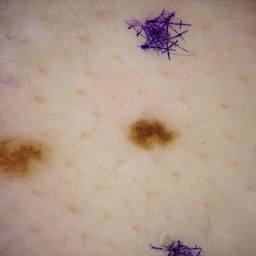

In [47]:
test_img = load_image(benign_samples_more[7])
test_img

# cleaned_img, hair_mask = remove_hair(test_img)

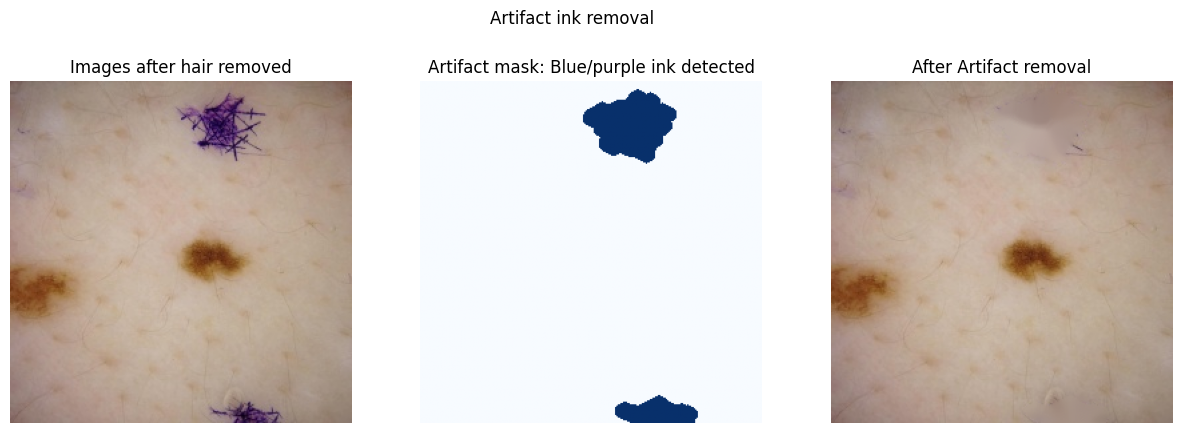

In [48]:
# Test on image
artifact_removed, artifact_mask = remove_artifacts(test_img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Artifact ink removal")

axes[0].imshow(test_img)
axes[0].set_title('Images after hair removed')
axes[0].axis('off')

axes[1].imshow(artifact_mask, cmap='Blues')
axes[1].set_title('Artifact mask: Blue/purple ink detected')
axes[1].axis('off')

axes[2].imshow(artifact_removed)
axes[2].set_title('After Artifact removal')
axes[2].axis('off')
plt.show()

### Surgical Ink Smearing Fix

**The Problem:**
During the removal of surgical marker artifacts, the `cv2.inpaint` (Telea) algorithm was initially leaving behind dark, blurry smudges instead of clean skin.

**The Root Cause:**
Surgical ink applied to skin is not uniformly opaque; it has a dark core but degrades into faint, semi-transparent purple edges. The initial strict HSV thresholding (`[100, 50, 50]`) successfully isolated the dark core but excluded the faint edges. Because those faded edges were left unmasked, the Telea algorithm interpreted them as "healthy skin" and mathematically dragged those dark pixels inward to fill the hole, creating the smudge.

**The Solution:**
Introduced **Morphological Dilation** to the binary mask prior to the inpainting step.

**Implementation:**
```python
# Create a circular kernel and dilate the mask
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
artifact_mask = cv2.dilate(artifact_mask, kernel, iterations=2)
```

**Why it Works:**
Dilation artificially inflates the boundaries of the binary mask, creating a buffer zone that completely swallows the faded ink edges. By expanding the mask slightly into the actual healthy skin, we guarantee that the inpainting algorithm's search radius (`inpaintRadius=7`) only samples true, unblemished skin pixels to reconstruct the excised area.

## Full Preprocessing Pipeline

In [49]:
def full_preprocess(img):
  """
  Run this on every image before training-
  Always do this orderwise:
  1. Hair removal
  2. Artifact removal
  3. Color Constancy
  """

  # `img` is already a NumPy array here because tf.py_function converts
  # TensorFlow tensors to NumPy arrays before calling this Python function.

  # step-1: Remove Hair
  img, _ = remove_hair(img)

  # Step-2: Artifact removal
  img, _ = remove_artifacts(img)

  # Step-3: Color constancy
  img = color_constancy(img)

  # Convert back to TensorFlow tensor
  return img


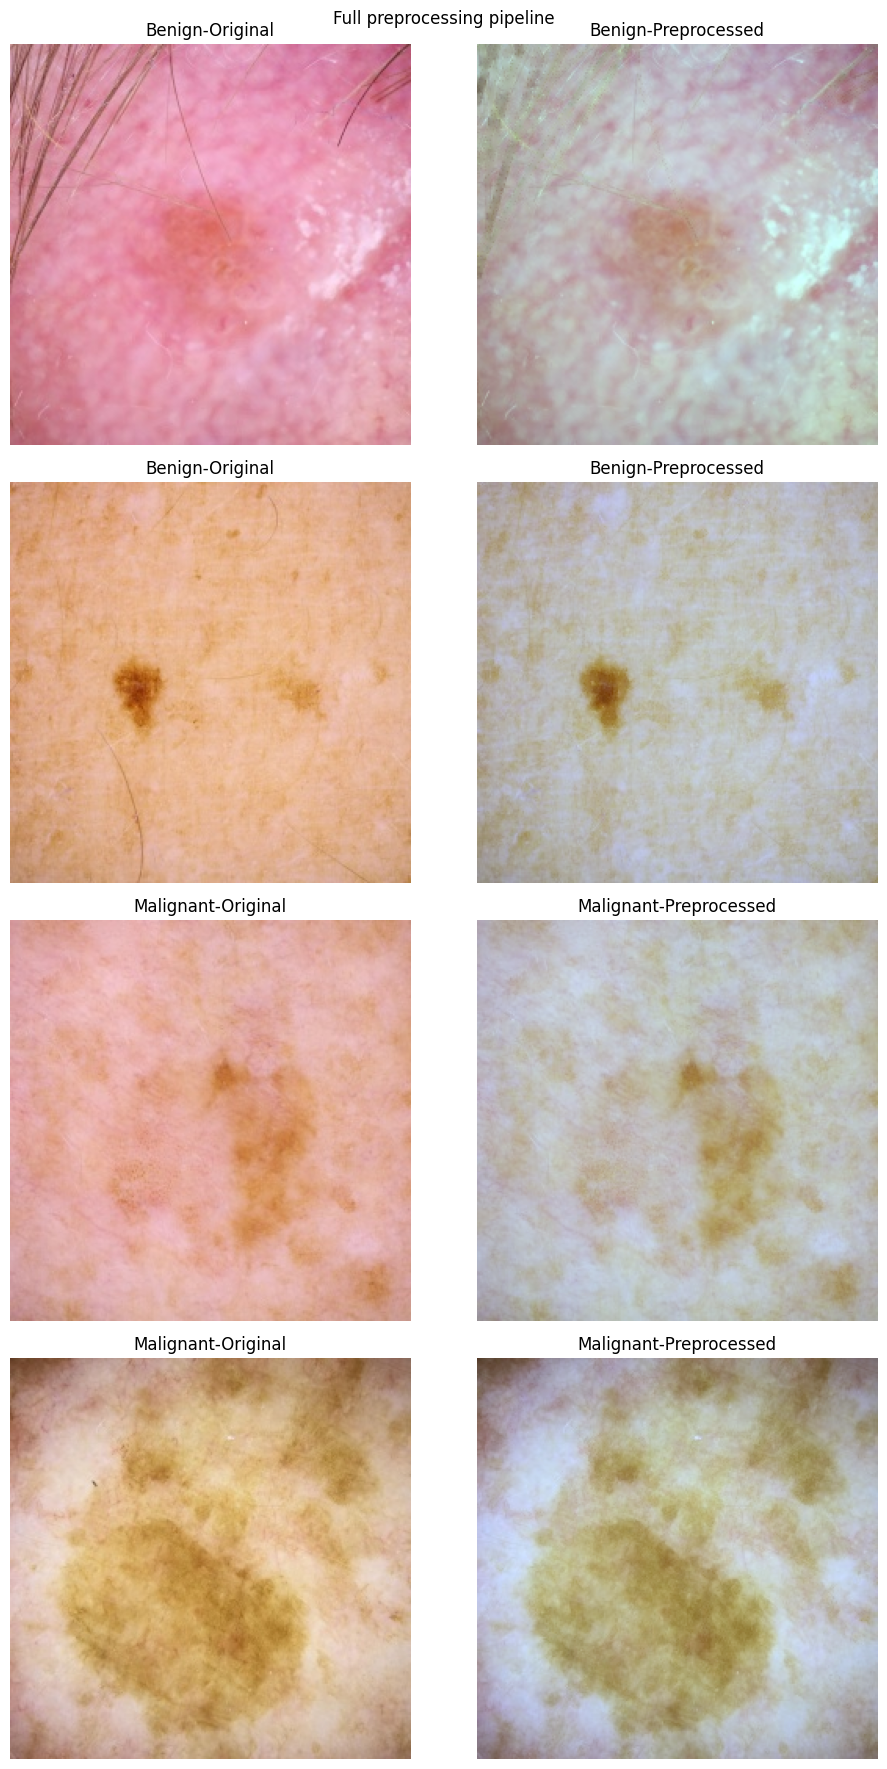

In [50]:
# Show the full pipeline on 4 images
fig, axes = plt.subplots(4, 2, figsize = (10, 18))
fig.suptitle("Full preprocessing pipeline")

sample_names = list(benign_samples[:2]) + list(malignant_samples[:2])
labels  = ['Benign', 'Benign', 'Malignant', 'Malignant']

for i, (name, label) in enumerate(zip(sample_names, labels)):
  original = load_image(name)
  processed = full_preprocess(original)

  axes[i, 0].imshow(original)
  axes[i, 0].set_title(f"{label}-Original")
  axes[i, 0].axis('off')

  axes[i, 1].imshow(processed)
  axes[i, 1].set_title(f"{label}-Preprocessed")
  axes[i, 1].axis('off')


plt.tight_layout()
plt.savefig('preprocessed.png')
plt.show()

### Problems Faced
During the development of this preprocessing pipeline, we encountered and resolved two critical computer vision bugs that caused catastrophic data loss. Documenting these ensures future scalability and acts as a guide for tuning hyperparameters on new datasets.

#### Case Study 1: The "Watercolor" Smudge (Artifact Removal)
**The Problem:**
Initial attempts to remove blue surgical marker ink using `cv2.INPAINT_TELEA` resulted in dark, blurry smudges rather than clean skin reconstruction.

**The Root Cause:**
Surgical ink is not uniformly opaque; it degrades into faint, semi-transparent purple at its edges. The initial HSV threshold strictly targeted the dark core of the ink but excluded these faint edges. Because the edges were left unmasked, the inpainting algorithm interpreted them as "healthy skin" and mathematically dragged those dark pixels inward to fill the masked hole, creating the smudge.

**The Fix:**
Implemented **Morphological Dilation** (`cv2.dilate`) immediately after the HSV thresholding. By artificially swelling the mask using a circular kernel, the mask completely engulfed the faded ink edges. This guaranteed that the inpainting algorithm's search radius only sampled true, unblemished skin pixels.

#### Case Study 2: Lesion Erasure & Geometric Artifacts (Resolution Scaling)
**The Problem:**
When the pipeline was applied to the downscaled `256x256` dataset, the algorithm completely erased actual melanoma lesions and replaced the entire image with massive geometric polygons.

**The Root Cause:**
The original morphological hyperparameters were tuned for high-resolution clinical images, which fundamentally clashed with the mathematical realities of a `256x256` image.
1.  **DullRazor Misfire:** A `17x17` Black-Hat kernel was originally used to target thick hairs. However, on a 256px image, a `17x17` pixel square is massive—so large that it mathematically classified entire small moles as "hair" and commanded the inpainting algorithm to erase the cancer.
2.  **Color Space Bleed:** The upper Hue bound for surgical ink was originally set to `170`. While `90-140` targets blue/purple, `150-170` shifts into magenta/pink. On highly inflamed (red/pink) skin, the algorithm classified the entire healthy skin as "surgical ink." The geometric polygons were the result of the inpainting algorithm failing because the mask covered 90% of the image.

**The Fix:**
The pipeline was recalibrated specifically for low-resolution spatial features:
*   **Kernel Shrinking:** Reduced the Black-Hat kernel from `17x17` to `5x5` and the inpainting radius to `2`. This ensured only microscopic line structures (actual hairs) were targeted, preserving the structural integrity of the lesions.
*   **Hue Capping:** Strictly capped the maximum HSV Hue bound at `150` to sever the overlap with pink/magenta skin, ensuring only artificial blue marker ink was masked.

## Engineering metadata Features


In [51]:
# Feature-1: No. of images per patient
## More lesions per patient = higher clinical suspicion:
# "Clinical suspicion" simply means how worried the doctor is that the patient might have cancer.
n_images = df.groupby('patient_id')['image_name'].count()
n_images

,image_name
patient_id,
IP_0001230,6
IP_0019713,13
IP_0036322,5
IP_0038436,3
IP_0038545,28
...,...
IP_9989332,10
IP_9992027,39
IP_9995095,14


In [52]:
n_images = df.groupby('patient_id')['image_name'].count().reset_index()
n_images.columns = ['patient_id', 'n_images_per_patient']
n_images

,patient_id,n_images_per_patient
0,IP_0001230,6
1,IP_0019713,13
2,IP_0036322,5
3,IP_0038436,3
4,IP_0038545,28
...,...,...
2051,IP_9989332,10
2052,IP_9992027,39
2053,IP_9995095,14
2054,IP_9996429,3


In [53]:
df = df.merge(n_images, on='patient_id', how='left')
df

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,n_images_per_patient
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0,115
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0,24
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0,5
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0,22
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0,20
...,...,...,...,...,...,...,...,...,...,...
33121,ISIC_9999134,IP_6526534,IL_2076932,male,50.0,torso,unknown,benign,0,36
33122,ISIC_9999320,IP_3650745,IL_6891604,male,65.0,torso,unknown,benign,0,33
33123,ISIC_9999515,IP_2026598,IL_6364820,male,20.0,lower extremity,unknown,benign,0,55
33124,ISIC_9999666,IP_7702038,IL_6048457,male,50.0,lower extremity,unknown,benign,0,29


In [54]:
# Feature-2: Encode sex as binary
df['sex_encoded'] = df['sex'].map({'male': 1, 'female': 0, 'unknown':0.5})
df

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,n_images_per_patient,sex_encoded
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0,115,1.0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0,24,0.0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0,5,0.0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0,22,0.0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0,20,0.0
...,...,...,...,...,...,...,...,...,...,...,...
33121,ISIC_9999134,IP_6526534,IL_2076932,male,50.0,torso,unknown,benign,0,36,1.0
33122,ISIC_9999320,IP_3650745,IL_6891604,male,65.0,torso,unknown,benign,0,33,1.0
33123,ISIC_9999515,IP_2026598,IL_6364820,male,20.0,lower extremity,unknown,benign,0,55,1.0
33124,ISIC_9999666,IP_7702038,IL_6048457,male,50.0,lower extremity,unknown,benign,0,29,1.0


In [55]:
# Feature 3: One-hot encode anatomical site
df = pd.get_dummies(df, columns=['anatom_site_general_challenge'], prefix='site')
df

,image_name,patient_id,lesion_id,sex,age_approx,diagnosis,benign_malignant,target,n_images_per_patient,sex_encoded,site_head/neck,site_lower extremity,site_oral/genital,site_palms/soles,site_torso,site_unknown,site_upper extremity
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,unknown,benign,0,115,1.0,True,False,False,False,False,False,False
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,unknown,benign,0,24,0.0,False,False,False,False,False,False,True
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,nevus,benign,0,5,0.0,False,True,False,False,False,False,False
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,unknown,benign,0,22,0.0,True,False,False,False,False,False,False
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,unknown,benign,0,20,0.0,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33121,ISIC_9999134,IP_6526534,IL_2076932,male,50.0,unknown,benign,0,36,1.0,False,False,False,False,True,False,False
33122,ISIC_9999320,IP_3650745,IL_6891604,male,65.0,unknown,benign,0,33,1.0,False,False,False,False,True,False,False
33123,ISIC_9999515,IP_2026598,IL_6364820,male,20.0,unknown,benign,0,55,1.0,False,True,False,False,False,False,False
33124,ISIC_9999666,IP_7702038,IL_6048457,male,50.0,unknown,benign,0,29,1.0,False,True,False,False,False,False,False


In [56]:
max_age = df['age_approx'].max()
min_age = df['age_approx'].min()
print(max_age)
print(min_age)

90.0
0.0


In [57]:
# Feature-4: Normalize the age(0 to 1)
# Min-max scaling = (Value - Min) / (Max - Min)
df['age_normalized'] = df['age_approx']/90.0
df

,image_name,patient_id,lesion_id,sex,age_approx,diagnosis,benign_malignant,target,n_images_per_patient,sex_encoded,site_head/neck,site_lower extremity,site_oral/genital,site_palms/soles,site_torso,site_unknown,site_upper extremity,age_normalized
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,unknown,benign,0,115,1.0,True,False,False,False,False,False,False,0.500000
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,unknown,benign,0,24,0.0,False,False,False,False,False,False,True,0.500000
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,nevus,benign,0,5,0.0,False,True,False,False,False,False,False,0.555556
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,unknown,benign,0,22,0.0,True,False,False,False,False,False,False,0.500000
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,unknown,benign,0,20,0.0,False,False,False,False,False,False,True,0.611111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33121,ISIC_9999134,IP_6526534,IL_2076932,male,50.0,unknown,benign,0,36,1.0,False,False,False,False,True,False,False,0.555556
33122,ISIC_9999320,IP_3650745,IL_6891604,male,65.0,unknown,benign,0,33,1.0,False,False,False,False,True,False,False,0.722222
33123,ISIC_9999515,IP_2026598,IL_6364820,male,20.0,unknown,benign,0,55,1.0,False,True,False,False,False,False,False,0.222222
33124,ISIC_9999666,IP_7702038,IL_6048457,male,50.0,unknown,benign,0,29,1.0,False,True,False,False,False,False,False,0.555556


In [58]:
# Feature 5: Log transform n_images- To correct (skewed distribution)
df['n_images_log'] = np.log1p(df['n_images_per_patient'])
df

,image_name,patient_id,lesion_id,sex,age_approx,diagnosis,benign_malignant,target,n_images_per_patient,sex_encoded,site_head/neck,site_lower extremity,site_oral/genital,site_palms/soles,site_torso,site_unknown,site_upper extremity,age_normalized,n_images_log
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,unknown,benign,0,115,1.0,True,False,False,False,False,False,False,0.500000,4.753590
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,unknown,benign,0,24,0.0,False,False,False,False,False,False,True,0.500000,3.218876
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,nevus,benign,0,5,0.0,False,True,False,False,False,False,False,0.555556,1.791759
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,unknown,benign,0,22,0.0,True,False,False,False,False,False,False,0.500000,3.135494
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,unknown,benign,0,20,0.0,False,False,False,False,False,False,True,0.611111,3.044522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33121,ISIC_9999134,IP_6526534,IL_2076932,male,50.0,unknown,benign,0,36,1.0,False,False,False,False,True,False,False,0.555556,3.610918
33122,ISIC_9999320,IP_3650745,IL_6891604,male,65.0,unknown,benign,0,33,1.0,False,False,False,False,True,False,False,0.722222,3.526361
33123,ISIC_9999515,IP_2026598,IL_6364820,male,20.0,unknown,benign,0,55,1.0,False,True,False,False,False,False,False,0.222222,4.025352
33124,ISIC_9999666,IP_7702038,IL_6048457,male,50.0,unknown,benign,0,29,1.0,False,True,False,False,False,False,False,0.555556,3.401197


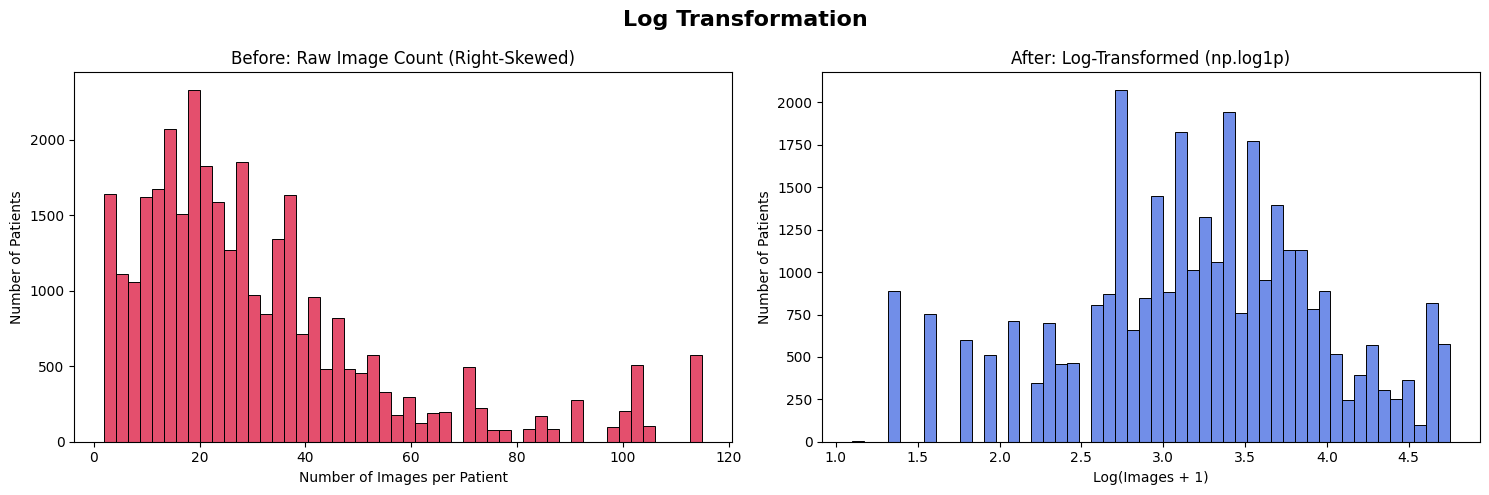

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Log Transformation", fontsize=16, fontweight='bold')

sns.histplot(df['n_images_per_patient'], bins=50, ax=axes[0], color='crimson')
axes[0].set_title('Before: Raw Image Count (Right-Skewed)')
axes[0].set_xlabel('Number of Images per Patient')
axes[0].set_ylabel('Number of Patients')

sns.histplot(df['n_images_log'], bins=50, ax=axes[1], color='royalblue')
axes[1].set_title('After: Log-Transformed (np.log1p)')
axes[1].set_xlabel('Log(Images + 1)')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

### Analysis: Log-Transforming Skewed Data

*   **Skewed Distribution:** Medical data often follows a "hockey stick" curve, where 95% of patients have 1–2 images while outliers have over 100.
*   **Weight Instability:** Raw outlier values (e.g., 150) cause neural network weights to violently overreact, ruining learning for "normal" cases.
*   **The Logarithmic Fix:** The `np.log1p` ($\ln(x+1)$) transformation "squashes" massive outliers to a manageable scale without changing their rank.
*   **Numerical Compression:** This mathematically shrinks a destructive 149-point gap (1 vs. 150) into a stable ~4.3 point difference ($0.69$ vs. $5.02$).
*   **Code Safety:** We use `log1p` to prevent mathematical errors or system crashes that occur when attempting to calculate the log of zero.

# Build train/validation split

we cannot split the images randomly... we need to use `GroupKFold`

In [60]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,       # We only need one Train/Val split (not multiple folds)
    test_size=0.2,
    random_state=42
)

# We tell the splitter to look at our dataframe, specifically grouping by 'patient_id'.
# The .split() method returns a generator, so we use next() to grab the first (and only) split it makes.
split_generator = splitter.split(df, groups=df['patient_id'])
train_indices, val_indices = next(split_generator)

df_train = df.iloc[train_indices].reset_index(drop=True)
df_val   = df.iloc[val_indices].reset_index(drop=True)

# If the overlap is not 0, the assert statement crashes the code and warns us.
assert len(set(df_train['patient_id']) & set(df_val['patient_id'])) == 0, "Patient leakage detected!"

In [61]:
# Print out the final stats to make sure our Malignant/Benign ratio is balanced
print(f"Train Dataset: {len(df_train)} images across {df_train['patient_id'].nunique()} unique patients")
print(f"Val Dataset:   {len(df_val)} images across {df_val['patient_id'].nunique()} unique patients")
print(f"Malignant Rate - Train: {df_train['target'].mean()*100:.2f}%, Val: {df_val['target'].mean()*100:.2f}%")

Train Dataset: 26161 images across 1644 unique patients
Val Dataset:   6965 images across 412 unique patients
Malignant Rate - Train: 1.75%, Val: 1.82%


In [63]:
# df_train.to_csv('/kaggle/working/train_processed.csv', index=False)
# df_val.to_csv('/kaggle/working/val_processed.csv', index=False)

In [64]:
# Paths
TRAIN_CSV  = '/content/drive/MyDrive/ISIC-training-csv/train_processed.csv'
VAL_CSV    = '/content/drive/MyDrive/ISIC-training-csv/val_processed.csv'
SAVE_DIR   = '/content/drive/MyDrive/ISIC-training-csv/weights'
os.makedirs(SAVE_DIR, exist_ok=True)

In [65]:
# Model parameters
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-4
LR_TUNE = 1e-5

In [66]:
# Focal loss
GAMMA = 2.0 # focus on hard examples
ALPHA = 0.25 # weight boost for malignant class

In [67]:
# Load CSV
df_train = pd.read_csv(TRAIN_CSV)
df_val = pd.read_csv(VAL_CSV)

In [68]:
df_train

,image_name,patient_id,lesion_id,sex,age_approx,diagnosis,benign_malignant,target,n_images_per_patient,sex_encoded,site_head/neck,site_lower extremity,site_oral/genital,site_palms/soles,site_torso,site_unknown,site_upper extremity,age_normalized,n_images_log
0,ISIC_1429439,IP_8140841,IL_7168087,male,75.0,unknown,benign,0,13,1.0,False,False,False,False,False,False,True,0.833333,2.639057
1,ISIC_0658963,IP_1870306,IL_6912137,male,75.0,unknown,benign,0,14,1.0,False,False,False,False,True,False,False,0.833333,2.708050
2,ISIC_7459410,IP_3722746,IL_7052071,male,50.0,nevus,benign,0,16,1.0,False,False,False,False,True,False,False,0.555556,2.833213
3,ISIC_7261174,IP_8041141,IL_5515845,female,15.0,melanoma,malignant,1,52,0.0,True,False,False,False,False,False,False,0.166667,3.970292
4,ISIC_1124744,IP_2610032,IL_5930399,male,40.0,nevus,benign,0,13,1.0,False,False,False,False,False,False,True,0.444444,2.639057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26495,ISIC_1929320,IP_3782995,IL_7989575,female,25.0,nevus,benign,0,34,0.0,False,False,False,False,True,False,False,0.277778,3.555348
26496,ISIC_3844983,IP_0825081,IL_1332454,male,80.0,unknown,benign,0,58,1.0,False,True,False,False,False,False,False,0.888889,4.077537
26497,ISIC_5366635,IP_7770083,IL_0385243,female,45.0,unknown,benign,0,34,0.0,False,False,False,False,False,True,False,0.500000,3.555348
26498,ISIC_5130558,IP_6078411,IL_8728019,male,35.0,unknown,benign,0,51,1.0,False,False,False,False,True,False,False,0.388889,3.951244


In [69]:
df_val

,image_name,patient_id,lesion_id,sex,age_approx,diagnosis,benign_malignant,target,n_images_per_patient,sex_encoded,site_head/neck,site_lower extremity,site_oral/genital,site_palms/soles,site_torso,site_unknown,site_upper extremity,age_normalized,n_images_log
0,ISIC_8105845,IP_7979366,IL_9430287,male,40.0,nevus,benign,0,16,1.0,False,False,False,False,True,False,False,0.444444,2.833213
1,ISIC_5147292,IP_3858753,IL_7166577,male,40.0,melanoma,malignant,1,42,1.0,False,True,False,False,False,False,False,0.444444,3.761200
2,ISIC_6524119,IP_1179846,IL_4421479,male,60.0,unknown,benign,0,21,1.0,False,True,False,False,False,False,False,0.666667,3.091042
3,ISIC_6874310,IP_0656529,IL_4897221,male,60.0,unknown,benign,0,114,1.0,False,False,False,False,False,False,True,0.666667,4.744932
4,ISIC_2754949,IP_8575171,IL_6280626,male,40.0,unknown,benign,0,22,1.0,False,False,False,False,True,False,False,0.444444,3.135494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6621,ISIC_7266307,IP_5221820,IL_2930128,female,50.0,unknown,benign,0,16,0.0,True,False,False,False,False,False,False,0.555556,2.833213
6622,ISIC_4929865,IP_5596716,IL_6255981,male,50.0,nevus,benign,0,16,1.0,False,True,False,False,False,False,False,0.555556,2.833213
6623,ISIC_7354733,IP_2962626,IL_2888691,female,30.0,unknown,benign,0,42,0.0,False,False,False,False,True,False,False,0.333333,3.761200
6624,ISIC_7688025,IP_2962626,IL_1827484,female,40.0,unknown,benign,0,42,0.0,False,True,False,False,False,False,False,0.444444,3.761200


In [70]:
# Dynamically group the metadata features
site_columns = [col for col in df_train.columns if col.startswith('site_')]
meta_features = ['sex_encoded', 'age_normalized', 'n_images_log'] + site_columns
num_meta_features = len(meta_features)

# Print a clean summary for verification
print(f"Training Set:   {len(df_train)} images (Malignant: {df_train['target'].sum()})")
print(f"Validation Set: {len(df_val)} images (Malignant: {df_val['target'].sum()})")
print(f"Metadata Count: {num_meta_features} features")
print(f"Metadata List:  {meta_features}")

# Critical Safety Checks (Fail-Fast)
assert 'image_name' in df_train.columns, "Error: 'image_name' column is missing!"
assert 'target' in df_train.columns, "Error: 'target' column is missing!"

Training Set:   26500 images (Malignant: 467)
Validation Set: 6626 images (Malignant: 117)
Metadata Count: 10 features
Metadata List:  ['sex_encoded', 'age_normalized', 'n_images_log', 'site_head/neck', 'site_lower extremity', 'site_oral/genital', 'site_palms/soles', 'site_torso', 'site_unknown', 'site_upper extremity']


In [71]:
# Verify images are actually accessible before building the model.
missing = 0
for name in df_train['image_name'].values[:5]:
    path = os.path.join(IMG_DIR, name + '.jpg')
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  {status}: {path}')
    if status == 'MISSING':
        missing += 1

if missing:
    print(f'\nWARNING: {missing} files missing. Check IMG_DIR and that unzip ran.')
else:
    print('\nAll images found. Ready to build model.')

  OK: /content/melanoma_data/train/ISIC_1429439.jpg
  OK: /content/melanoma_data/train/ISIC_0658963.jpg
  OK: /content/melanoma_data/train/ISIC_7459410.jpg
  OK: /content/melanoma_data/train/ISIC_7261174.jpg
  OK: /content/melanoma_data/train/ISIC_1124744.jpg

All images found. Ready to build model.


In [72]:
from tensorflow.keras import layers, Sequential

# Data Augmentation
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=0.5), # 0.5 means any random angle from 0 to 360 degrees
    layers.RandomBrightness(factor=0.2) # Randomly makes it 20% darker or brighter
], name="augmentation_layer")

In [73]:
df[df['target'] == 0]

,image_name,patient_id,lesion_id,sex,age_approx,diagnosis,benign_malignant,target,n_images_per_patient,sex_encoded,site_head/neck,site_lower extremity,site_oral/genital,site_palms/soles,site_torso,site_unknown,site_upper extremity,age_normalized,n_images_log
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,unknown,benign,0,115,1.0,True,False,False,False,False,False,False,0.500000,4.753590
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,unknown,benign,0,24,0.0,False,False,False,False,False,False,True,0.500000,3.218876
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,nevus,benign,0,5,0.0,False,True,False,False,False,False,False,0.555556,1.791759
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,unknown,benign,0,22,0.0,True,False,False,False,False,False,False,0.500000,3.135494
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,unknown,benign,0,20,0.0,False,False,False,False,False,False,True,0.611111,3.044522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33121,ISIC_9999134,IP_6526534,IL_2076932,male,50.0,unknown,benign,0,36,1.0,False,False,False,False,True,False,False,0.555556,3.610918
33122,ISIC_9999320,IP_3650745,IL_6891604,male,65.0,unknown,benign,0,33,1.0,False,False,False,False,True,False,False,0.722222,3.526361
33123,ISIC_9999515,IP_2026598,IL_6364820,male,20.0,unknown,benign,0,55,1.0,False,True,False,False,False,False,False,0.222222,4.025352
33124,ISIC_9999666,IP_7702038,IL_6048457,male,50.0,unknown,benign,0,29,1.0,False,True,False,False,False,False,False,0.555556,3.401197


In [74]:
### Oversampling the malignant samples

def oversample_malignant(df):
  benign = df[df['target'] == 0]
  malignant = df[df['target'] == 1]

  # Duplicate malignant rows 10x
  mal_10x = pd.concat([malignant]*10, ignore_index=True)

  # Combine and Shuffle
  balanced_df = pd.concat([benign, mal_10x]).sample(frac=1, random_state=42).reset_index(drop=True)
  print(f"Oversampled: Benign = {len(benign)},   Malignant = {len(mal_10x)}")

  return balanced_df

In [75]:
### Loading images
def process_data(img_name, meta_vector, label):

  # build the path and load image
  img_path = tf.strings.join([IMG_DIR, '/', img_name, '.jpg'])
  img_raw = tf.io.read_file(img_path)
  img = tf.image.decode_jpeg(img_raw, channels=3)

  # Applying custom OpenCV preprocessing pipeline
  # tf.py_function let us safely run python/openCV code in cpu
  img = tf.py_function(func=full_preprocess, inp=[img], Tout=tf.uint8)

  # Explicitly set the shape after py_function so tf.image.resize works
  img.set_shape([None, None, 3])

  # Resize and normalize
  img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
  img = tf.cast(img, tf.float32) / 255.0

  return (img, meta_vector), label

 DullRazor morphological preprocessing was written in CPU-bound OpenCV. I used `tf.py_function` to safely wrap that Python logic inside the C++ TensorFlow graph. I know it creates an I/O bottleneck, but preserving the medical integrity of the images was more critical than raw training speed for this dataset

In [76]:
def build_dataset(df, is_training = False):
  """ Converts the dataframe into a fast tf.data pipeline. """

  # Extract columns into arrays
  names = df['image_name'].values
  metas = df[meta_features].values.astype('float32')
  labels = df['target'].values.astype('float32')

  # Create the base dataset
  ds = tf.data.Dataset.from_tensor_slices((names, metas, labels))

  if is_training:
    # Shuffle the data
    ds = ds.shuffle(buffer_size=5000)

  # Map the processing function across CPU cores simultaneously
  ds = ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)

  # Batch the data and Pre-fetch (load batch 2 while GPU trains on batch 1)
  ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

  return ds

In [77]:
df_train_balanced = oversample_malignant(df_train)

# Generate the final pipelines:
train_gen = build_dataset(df_train_balanced, is_training=True)
val_gen = build_dataset(df_val, is_training=False)

Oversampled: Benign = 26033,   Malignant = 4670


In [78]:
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Recall, Precision, TruePositives, FalseNegatives, TrueNegatives, FalsePositives

In [79]:
# ----------- Branch-1: Visual Data -----------
def build_image_branch(IMG_SIZE):
  """Handles all visual feature extraction."""

  img_in = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name = 'image_input')

  # apply data augmentation
  x = data_augmentation(img_in)

  backbone = EfficientNetV2B0(
      include_top=False,
      weights = 'imagenet',
      pooling = 'avg'
  )

  backbone.trainable = False

  x = backbone(x)

  img_features = layers.Dropout(0.3)(x)

  # Return both entry point and final features
  return img_in, img_features

In [80]:
# ----------- Branch-2: Metadata Brach -----------
def build_metadata_branch(n_features):
  """Handles all clinical tabular data."""

  meta_in = Input(shape=(n_features,), name='metadata_input')

  m = layers.BatchNormalization()(meta_in)
  m = layers.Dense(64, activation='relu')(m)
  m = layers.Dropout(0.2)(m)
  meta_features = layers.Dense(32, activation='relu')(m)

  # return both entrypoint and final features
  return meta_in, meta_features

In [81]:
def build_fusion_model(IMG_SIZE, n_meta_features, lr):
  """Assembles the branches and adds the decision head."""

  # Grab the input and features from the modular branch
  img_input, img_features = build_image_branch(IMG_SIZE)
  meta_input, meta_features = build_metadata_branch(n_meta_features)

  # Merge them (Late Fusion)
  merged = layers.Concatenate()([img_features, meta_features])

  # Decision head
  f = layers.Dense(256, activation='relu')(merged)
  f = layers.Dropout(0.4)(f)
  output = layers.Dense(1, activation='sigmoid', name='output')(f)

  # Assemble and compile
  model = Model(inputs=[img_input, meta_input], outputs=output)

  model.compile(
      optimizer = tf.keras.optimizers.Adam(learning_rate=lr),
      loss = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, alpha=0.25),
      metrics = [

          AUC(name='auc'),
          BinaryAccuracy(name='accuracy', threshold=0.22),

          Recall(name='recall', thresholds=0.22),
          Precision(name='precision', thresholds=0.22),

          # The Raw Counts (To monitor exactly what is happening)
          TruePositives(name='tp'),
          FalseNegatives(name='fn'), # Worst possible mistake

          TrueNegatives(name='tn'),
          FalsePositives(name='fp')
      ]
  )

  return model

In [82]:
# build the final model
model = build_fusion_model(IMG_SIZE=IMG_SIZE, n_meta_features=num_meta_features, lr=LR)

print(f"Modular Fusion Model built successfully.")
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Modular Fusion Model built successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ metadata_input      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10)        │         40 │ metadata_input[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation_layer  │ (None, 256, 256,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 1280)      │  5,919,312 │ augmentation_lay… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1312)      │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    336,128 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,258,521 (23.87 MB)

 Trainable params: 339,189 (1.29 MB)

 Non-trainable params: 5,919,332 (22.58 MB)

In [83]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, BackupAndRestore

# Autosaver: Saves the best version of the model
checkpoint = ModelCheckpoint(
    filepath = '/kaggle/working/best_fusion_model.keras',
    monitor = 'val_auc',
    save_best_only = True,
    mode = 'max'
)

# Stops training if AUC dosen't improve for 6 epochs
early_stop = EarlyStopping(
    monitor = 'val_auc',
    patience = 6,
    restore_best_weights = True
)

# Slows down training when model gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor = 'val_auc',
    factor = 0.5,
    patience = 3
)

# Backup Drive
csv_log = CSVLogger('training_history.csv')

# Colab crash protector
backup = BackupAndRestore(
    backup_dir = '/kaggle/working/Melanoma_project_backup'
)


# Bundle all of them together
my_callbacks = [checkpoint, early_stop, reduce_lr, csv_log, backup]


## Training in 2 phases:

#### Phase-1: Custom Head Training


In [ ]:
# print(" Phase-1: Custom Head Training (Backbone frozen) \n")

# history1 = model.fit(
#     train_gen,
#     validation_data = val_gen,
#     epochs = 5,
#     callbacks= my_callbacks,
#     verbose=1
# )

In [ ]:
# # Best accuracy achieved in phase 1
# max_acc = max(history1.history['val_auc'])
# print(f"Phase 1 best val AUC: {max_acc}")

#### Phase-2: Fine Tuning (Full Model Unfrozen)

In [85]:
print("PHASE 2: Fine-Tuning (Full Model Unfrozen)")

# Unfreeze the backbone
conv_base = model.get_layer('efficientnetv2-b0')
conv_base.trainable = True

# Recompile with Tiny learning rate
LR_TUNE = 1e-5  # this must be very small

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR_TUNE),
    loss = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, alpha=0.25),
    metrics = [

      AUC(name='auc'),
      BinaryAccuracy(name='accuracy', threshold=0.22),

      Recall(name='recall', thresholds=0.22),
      Precision(name='precision', thresholds=0.22),

      # The Raw Counts (To monitor exactly what is happening)
      TruePositives(name='tp'),
      FalseNegatives(name='fn'), # Worst possible mistake

      TrueNegatives(name='tn'),
      FalsePositives(name='fp')
    ]

)

model.summary()

PHASE 2: Fine-Tuning (Full Model Unfrozen)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ metadata_input      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10)        │         40 │ metadata_input[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation_layer  │ (None, 256, 256,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 1280)      │  5,919,312 │ augmentation_lay… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1312)      │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    336,128 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,258,521 (23.87 MB)

 Trainable params: 6,197,893 (23.64 MB)

 Non-trainable params: 60,628 (236.83 KB)

In [86]:
# print("Phase-2: Training starts")

# history2 = model.fit(
#     train_gen,
#     validation_data = val_gen,
#     epochs = 40,
#     callbacks = my_callbacks,
#     verbose=1
# )

In [87]:
# # Print final results
# best_phase1 = max(history1.history['val_auc'])
# best_phase2 = max(history2.history['val_auc'])

# print(f'Best Phase 1 AUC: {best_phase1:.4f}')
# print(f'Best Phase 2 AUC: {best_phase2:.4f}')
# print(f'Overall Best AUC: {max(best_phase1, best_phase2):.4f}')

## Training Results Summary

**Architecture:** EfficientNetV2-B0 + Late Metadata Fusion  
**Training:** 2-phase   
**Best val AUC:** 0.8624 (epoch 27, saved by ModelCheckpoint)  

**Note on train vs val AUC gap:**  
Val AUC (0.86) consistently exceeds train AUC (0.79) throughout training.  
This is expected: the training set uses 10× oversampled malignant cases  
(harder balanced classification problem), while the validation set uses  
the natural ~1.75% positive rate (easier ranking problem).  
This is not data leakage — it reflects the oversampling strategy working  
as intended. The val set uses original class distribution, making it  
the honest estimate of real-world performance.

# Evaluation

In [88]:
MODEL_PATH = '/content/drive/MyDrive/ISIC-Skin-cancer-dataset/best_fusion_model.keras'
TRAINING_HISTORY_PATH = '/content/drive/MyDrive/ISIC-Skin-cancer-dataset/training_history.csv'

In [89]:
# Load the best saved model
best_model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# Extract labels FIRST before predict() exhausts the generator
y_true = np.concatenate([y.numpy() for _, y in val_gen])

y_prob = best_model.predict(val_gen).flatten()

208/208 ━━━━━━━━━━━━━━━━━━━━ 77s 354ms/step


In [136]:
THRESHOLD = 0.18

In [137]:
from sklearn.metrics import roc_auc_score, confusion_matrix, recall_score

# 1. Calculate overall AUC (Area Under the Curve)
auc = roc_auc_score(y_true, y_prob)

# 2. Apply your custom clinical threshold (0.15)
# If probability is >= 0.18, predict 1 (Malignant). Otherwise, 0 (Benign).
y_pred = (y_prob >= THRESHOLD).astype(int)

# 3. Build the Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# 4. Calculate Sensitivity and Specificity
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

In [138]:
from sklearn.utils import resample
import numpy as np

# 1. Run 1000 simulated evaluations
boot_aucs = [roc_auc_score(y_true[idx], y_prob[idx])
             for idx in (resample(range(len(y_true))) for _ in range(1000))]

print(f"Bootstrap complete: {len(boot_aucs)} samples") # should print 1000

# 2. Find the 2.5th and 97.5th percentiles to get the 95% range
ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])

# 3. Print the final clinical report
print("=" * 50)
print(f"  AUC:         {auc:.4f}  (95% CI: {ci_low:.4f}–{ci_high:.4f})")
print(f"  Sensitivity: {sensitivity*100:.1f}%  (TP={tp}, FN={fn})")
print(f"  Specificity: {specificity*100:.1f}%  (TN={tn}, FP={fp})")
print(f"  Threshold:   0.18")
print("=" * 50)

Bootstrap complete: 1000 samples
  AUC:         0.8541  (95% CI: 0.8237–0.8865)
  Sensitivity: 98.3%  (TP=115, FN=2)
  Specificity: 31.7%  (TN=2061, FP=4448)
  Threshold:   0.18


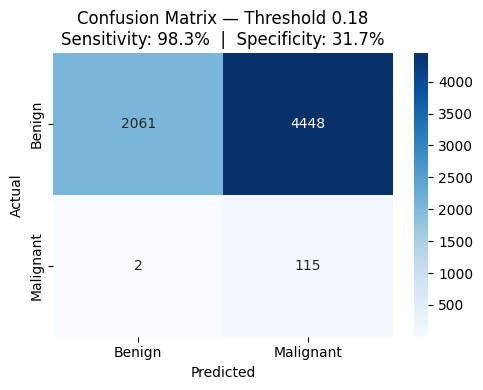

In [139]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix — Threshold 0.18\nSensitivity: {sensitivity*100:.1f}%  |  Specificity: {specificity*100:.1f}%')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

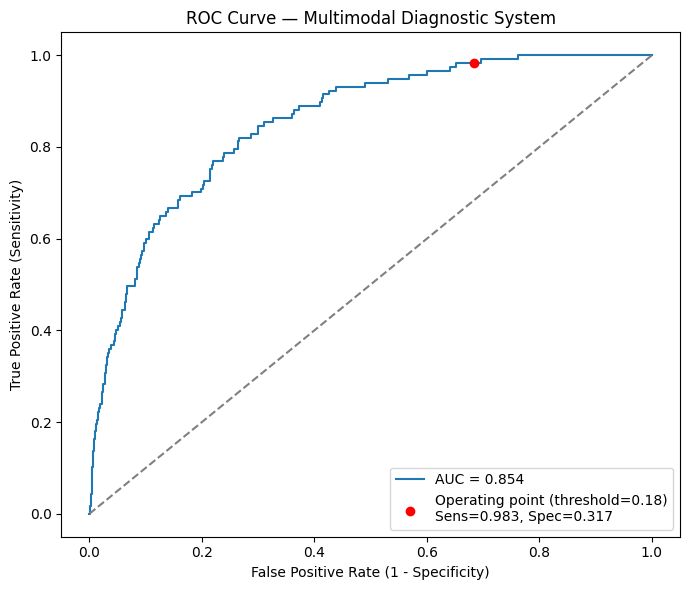

In [122]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# 1. Calculate the curve points
fpr, tpr, _ = roc_curve(y_true, y_prob)

# 2. Set up the canvas
plt.figure(figsize=(7, 6))

# 3. Draw the main AUC curve
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')

# 4. Plot the red "Operating Point" dot based on your 0.20 threshold
plt.scatter([1-specificity], [sensitivity], color='red', zorder=5,
            label=f'Operating point (threshold=0.18)\nSens={sensitivity:.3f}, Spec={specificity:.3f}')

# 5. Draw the random guessing baseline (diagonal line)
plt.plot([0,1],[0,1],'--', color='gray')

# 6. Add labels, title, and save the image
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Multimodal Diagnostic System')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# Threshold finding

In [94]:
trained_model = tf.keras.models.load_model(MODEL_PATH)

In [95]:
history_df = pd.read_csv(TRAINING_HISTORY_PATH)
history_df

,epoch,accuracy,auc,fn,fp,learning_rate,loss,precision,recall,tn,tp,val_accuracy,val_auc,val_fn,val_fp,val_loss,val_precision,val_recall,val_tn,val_tp
0,0,0.220916,0.684968,3519.0,2185.0,1.000000e-05,0.120217,0.159236,0.972210,23519.0,1051.0,0.141852,0.786617,103.0,109.0,0.044919,0.020177,0.968504,6729.0,24.0
1,1,0.228612,0.734553,3901.0,469.0,1.000000e-05,0.098945,0.161580,0.981182,25235.0,669.0,0.084279,0.794825,95.0,153.0,0.049594,0.019376,0.992126,6685.0,32.0
2,2,0.244731,0.744249,3920.0,431.0,1.000000e-05,0.097635,0.164743,0.983589,25273.0,650.0,0.222828,0.825039,100.0,132.0,0.045274,0.022579,0.984252,6706.0,27.0
3,3,0.255202,0.756614,3891.0,438.0,1.000000e-05,0.096286,0.166630,0.983151,25266.0,679.0,0.225844,0.830002,102.0,126.0,0.045735,0.022665,0.984252,6712.0,25.0
4,4,0.272379,0.760122,3873.0,451.0,5.000000e-06,0.095804,0.169431,0.978993,25253.0,697.0,0.262742,0.840808,100.0,109.0,0.044659,0.023954,0.992126,6729.0,27.0
5,5,0.272709,0.765116,3836.0,422.0,5.000000e-06,0.094792,0.170345,0.986433,25282.0,734.0,0.349174,0.847786,112.0,68.0,0.038702,0.026644,0.976378,6770.0,15.0
6,6,0.285162,0.770252,3826.0,482.0,5.000000e-06,0.094348,0.172405,0.982932,25222.0,744.0,0.330079,0.850251,97.0,126.0,0.042814,0.026299,0.992126,6712.0,30.0
7,7,0.288168,0.776037,3753.0,471.0,2.500000e-06,0.093319,0.172908,0.982057,25233.0,817.0,0.494329,0.855959,109.0,80.0,0.033020,0.032755,0.937008,6758.0,18.0
8,8,0.301810,0.780444,3808.0,491.0,2.500000e-06,0.092835,0.176033,0.984902,25213.0,762.0,0.415363,0.852160,97.0,116.0,0.037668,0.029349,0.968504,6722.0,30.0
9,9,0.304188,0.780510,3741.0,511.0,2.500000e-06,0.092827,0.176226,0.982276,25193.0,829.0,0.444078,0.854282,100.0,108.0,0.036343,0.030113,0.944882,6730.0,27.0


In [123]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, recall_score, precision_score

y_pred_prob = best_model.predict(val_gen)

# 2. Get the actual ground-truth labels (0 for Benign, 1 for Malignant)
y_true = []
for _, labels in val_gen:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# 3. Create a list of thresholds to test (from 0.05 up to 0.50)
thresholds_to_test = np.arange(0.05, 0.55, 0.05)
results = []

for t in thresholds_to_test:
    # Convert probabilities to 1s and 0s based on the current threshold 't'
    y_pred_binary = (y_pred_prob > t).astype(int)

    # Calculate exactly how many the model got right and wrong
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()

    # Calculate the crucial metrics
    recall = recall_score(y_true, y_pred_binary)
    precision = precision_score(y_true, y_pred_binary, zero_division=0)

    # Store the results
    results.append({'Threshold': t, 'Caught (TP)': tp, 'Missed (FN)': fn, 'False Alarms (FP)': fp})

# 4. Display the results in a clean table
print(pd.DataFrame(results))

208/208 ━━━━━━━━━━━━━━━━━━━━ 69s 331ms/step
   Threshold  Caught (TP)  Missed (FN)  False Alarms (FP)
0       0.05          117            0               6456
1       0.10          117            0               5769
2       0.15          116            1               4964
3       0.20          113            4               4100
4       0.25          109            8               3089
5       0.30           99           18               1978
6       0.35           81           36               1080
7       0.40           59           58                526
8       0.45           41           76                216
9       0.50           24           93                 94


I am going to choose Threshold = 0.18 (between 0.15 and 0.20)

##3 Generate TTA Probabilities

In [124]:
tta_predictions = []
y_true_tta = []

# Loop through the validation generator batch-by-batch
for (images, meta), labels in val_gen:
    # 1. Save the ground truth labels
    y_true_tta.extend(labels.numpy())

    # 2. Create the 5 Augmented Views
    batch_1 = images                                # Original
    batch_2 = tf.image.flip_left_right(images)      # Horizontal Flip
    batch_3 = tf.image.flip_up_down(images)         # Vertical Flip
    batch_4 = tf.image.rot90(images, k=1)           # Rotate 90 degrees
    batch_5 = tf.image.rot90(images, k=3)           # Rotate 270 degrees

    # 3. Get predictions
    pred_1 = trained_model([batch_1, meta], training=False)
    pred_2 = trained_model([batch_2, meta], training=False)
    pred_3 = trained_model([batch_3, meta], training=False)
    pred_4 = trained_model([batch_4, meta], training=False)
    pred_5 = trained_model([batch_5, meta], training=False)

    # 4. Average the 5 scores to get the final TTA probability
    avg_preds = (pred_1 + pred_2 + pred_3 + pred_4 + pred_5) / 5.0
    tta_predictions.extend(avg_preds.numpy())

# Convert to clean numpy arrays for fast math
tta_predictions = np.array(tta_predictions)
y_true_tta = np.array(y_true_tta)

### PHASE 2: TEST ALL THRESHOLDS ON TTA SCORES

In [125]:
results_table = []
# Testing thresholds from 0.10 up to 0.50
thresholds_to_test = np.arange(0.05, 0.55, 0.05)

for t in thresholds_to_test:
    # 1. Apply the test threshold to our newly generated TTA probabilities
    y_pred_binary = (tta_predictions >= t).astype(int)

    # 2. Calculate right/wrong predictions
    tn, fp, fn, tp = confusion_matrix(y_true_tta, y_pred_binary).ravel()

    # 3. Calculate clinical metrics safely
    recall = recall_score(y_true_tta, y_pred_binary)
    precision = precision_score(y_true_tta, y_pred_binary, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # 4. Save the row for the table
    results_table.append({
        'Threshold': f"{t:.2f}",
        'Recall(Catch Rate)': f"{recall:.3f}",
        'Specificity': f"{specificity*100:.2f}%",
        'Caught (TP)': tp,
        'Missed (FN)': fn,
        'False Alarms (FP)': fp
    })

### PHASE 3: DISPLAY THE FINAL REPORT

In [126]:
print("="*65)
print(" ULTIMATE TTA THRESHOLD OPTIMIZATION TABLE ")
print("="*65)
print(pd.DataFrame(results_table).to_string(index=False))

 ULTIMATE TTA THRESHOLD OPTIMIZATION TABLE 
Threshold Recall(Catch Rate) Specificity  Caught (TP)  Missed (FN)  False Alarms (FP)
     0.05              1.000       0.51%          117            0               6476
     0.10              1.000      10.71%          117            0               5812
     0.15              1.000      23.26%          117            0               4995
     0.20              0.983      36.96%          115            2               4103
     0.25              0.915      52.77%          107           10               3074
     0.30              0.829      70.16%           97           20               1942
     0.35              0.692      83.24%           81           36               1091
     0.40              0.513      92.27%           60           57                503
     0.45              0.325      96.84%           38           79                206
     0.50              0.222      98.62%           26           91                 90


In [128]:
results_table = []
# Testing thresholds from 0.10 up to 0.50
thresholds_to_test = np.arange(0.10, 0.30, 0.01)

for t in thresholds_to_test:
    # 1. Apply the test threshold to our newly generated TTA probabilities
    y_pred_binary = (tta_predictions >= t).astype(int)

    # 2. Calculate right/wrong predictions
    tn, fp, fn, tp = confusion_matrix(y_true_tta, y_pred_binary).ravel()

    # 3. Calculate clinical metrics safely
    recall = recall_score(y_true_tta, y_pred_binary)
    precision = precision_score(y_true_tta, y_pred_binary, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # 4. Save the row for the table
    results_table.append({
        'Threshold': f"{t:.2f}",
        'Recall(Catch Rate)': f"{recall:.3f}",
        'Specificity': f"{specificity*100:.2f}%",
        'Caught (TP)': tp,
        'Missed (FN)': fn,
        'False Alarms (FP)': fp
    })

In [129]:
print("="*65)
print(" ULTIMATE TTA THRESHOLD OPTIMIZATION TABLE ")
print("="*65)
print(pd.DataFrame(results_table).to_string(index=False))

 ULTIMATE TTA THRESHOLD OPTIMIZATION TABLE 
Threshold Recall(Catch Rate) Specificity  Caught (TP)  Missed (FN)  False Alarms (FP)
     0.10              1.000      10.71%          117            0               5812
     0.11              1.000      13.12%          117            0               5655
     0.12              1.000      15.59%          117            0               5494
     0.13              1.000      18.11%          117            0               5330
     0.14              1.000      20.85%          117            0               5152
     0.15              1.000      23.26%          117            0               4995
     0.16              0.991      25.66%          116            1               4839
     0.17              0.983      28.51%          115            2               4653
     0.18              0.983      31.53%          115            2               4457
     0.19              0.983      34.17%          115            2               4285
     0.20 

I will select the `Threshold = 0.18`